# AlphaMissense Ambiguous Variants in CYP Proteins

Demonstrates that the 6 CYP proteins studied here have a higher fraction of **ambiguous** AlphaMissense predictions than the genome-wide average reported in the AlphaMissense paper. Also looks at the abundance decomposition of CYP2C9 variants, and biological/structural priors that may explain AM's error.

**Genome-wide reference (AlphaMissense paper):**
- Total missense variants: 71 million
- Likely pathogenic: 22.8 million (32%)
- Likely benign: 40.9 million (57%)
- **Ambiguous: 7.3 million (~10.3%)**

## Required input files

All paths below are relative to this notebook, i.e. `DATA_DIR = '../data'`:

| Path | Description |
|---|---|
| `AlphaMissense-Search-P*.tsv` | AlphaMissense pathogenicity score/class TSVs, one per UniProt accession. 6 CYP proteins (CYP1A2, CYP2C19, CYP2C9, CYP2D6, CYP2E1, CYP3A4) plus 6 non-CYP control proteins (ACTB, ALB, HBA1, IGHG1, INS, TNF). |
| `query-detected.sses.json` | SecStrAnnotator secondary-structure element assignments for the CYP2C9 structure (structure-chain indexed). |
| `query-sequence.json` | SecStrAnnotator query sequence metadata, used to derive the structure-to-protein coordinate offset. |
| `cyp2c9_srs_annotated.sses.json` | SecStrAnnotator output: CYP2C9 AlphaFold model annotated against SecStrAnnotator's own CYP450-fold reference template (PDB 2NNJ chain A), giving canonical helix/strand labels (B', F, G, I, 1-4, 1-5, 4-1, 4-2) matched to real CYP2C9 residue ranges. Used to define SRS1-6 for the priors-vs-prediction-error distance test. |
| `AF-P11712-F1-model_v6.pdb` | AlphaFold structure of CYP2C9 (UniProt P11712), used for Cα distance-to-heme-proxy calculations. |
| `masked_marginal_prob.json` | ESM-2 masked-marginal log-likelihood ratios per CYP2C9 variant, aggregated here to a per-position conservation score. |
| `am_calibrated_error.csv` | AM-calibrated OOF click-seq prediction error per variant. **Produced by `cyp2c9_activity_prediction.ipynb`** -- run that notebook first. |
| `pharmvar_cyp2c9_missense_mutations_single.csv` | PharmVar missense allele definitions for CYP2C9 (also used in `cyp2c9_activity_prediction.ipynb`); resolves ClinPGx star alleles to protein variants. |
| `clinpgx_cyp2c9_variants.tsv` | ClinPGx (PharmGKB) CYP2C9 variant-drug literature annotations, used for the substrate-discordance analysis. |
| `drug_smiles_cyp.csv` | Drug-to-CYP substrate mapping, used to restrict ClinPGx drug annotations to documented CYP2C9 substrates. |
| `cyp2c9.csv` | Deep mutational scanning data: VAMP-seq abundance and CLICK-seq activity scores for CYP2C9 variants (Amorosi et al.); used for the in-house empirical rheostat/toggle/neutral classification. |


In [1]:
import glob
import json
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns
from Bio import PDB
from scipy import stats
from scipy.stats import (
    binomtest, chi2_contingency, chisquare, spearmanr, kruskal, mannwhitneyu,
)
from scipy.ndimage import gaussian_filter1d
from scipy.spatial.distance import cdist
from statsmodels.stats.multitest import multipletests

# ── Publication-quality figure defaults ───────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':         150,
    'savefig.dpi':         300,
    'font.family':         'sans-serif',
    'font.sans-serif':     ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size':           11,
    'axes.titlesize':      13,
    'axes.titleweight':    'bold',
    'axes.labelsize':      12,
    'xtick.labelsize':     10,
    'ytick.labelsize':     10,
    'legend.fontsize':     10,
    'legend.frameon':      True,
    'legend.framealpha':   0.85,
    'legend.facecolor':    'white',
    'legend.edgecolor':    '0.8',
    'axes.spines.top':     False,
    'axes.spines.right':   False,
    'axes.linewidth':      0.8,
    'lines.linewidth':     1.2,
})

DATA_DIR = '../data'


## Genome-wide reference from the AlphaMissense paper

In [2]:
# From AlphaMissense paper (Cheng et al., Science 2023)
GENOME_TOTAL      = 71_000_000
GENOME_PATHOGENIC = 22_800_000  # 32%
GENOME_BENIGN     = 40_900_000  # 57%
GENOME_AMBIGUOUS  = GENOME_TOTAL - GENOME_PATHOGENIC - GENOME_BENIGN  # ~7.3M

GENOME_PCT = {
    'likely_pathogenic': GENOME_PATHOGENIC / GENOME_TOTAL * 100,
    'likely_benign':     GENOME_BENIGN     / GENOME_TOTAL * 100,
    'ambiguous':         GENOME_AMBIGUOUS  / GENOME_TOTAL * 100,
}

print('Genome-wide AlphaMissense class distribution (from AlphaMissensepaper):')
for cls, pct in GENOME_PCT.items():
    n = {'likely_pathogenic': GENOME_PATHOGENIC,
         'likely_benign':     GENOME_BENIGN,
         'ambiguous':         GENOME_AMBIGUOUS}[cls]
    print(f'  {cls:<22}: {n/1e6:.3f}M  ({pct:.3f}%)')

Genome-wide AlphaMissense class distribution (from AlphaMissensepaper):
  likely_pathogenic     : 22.800M  (32.113%)
  likely_benign         : 40.900M  (57.606%)
  ambiguous             : 7.300M  (10.282%)


## Load AlphaMissense predictions for all 6 CYP proteins

In [3]:
tsv_files = sorted(glob.glob(f'{DATA_DIR}/AlphaMissense-Search-P*.tsv'))
print(f'Found {len(tsv_files)} TSV files:')
for f in tsv_files:
    print(f'  {f}')

cyp_dfs = []
non_cyp_dfs = []
for f in tsv_files:
    df = pd.read_csv(f, sep='\t')
    df.columns = df.columns.str.lstrip('# ')
    if df['Gene name'].iloc[0].startswith('CYP'):
        cyp_dfs.append(df)
    else:
        non_cyp_dfs.append(df)

all_cyp = pd.concat(cyp_dfs, ignore_index=True)
print(f'\nCYP variants loaded: {len(all_cyp):,}  ({len(cyp_dfs)} proteins)')

if non_cyp_dfs:
    all_non_cyp = pd.concat(non_cyp_dfs, ignore_index=True)
    print(f'Non-CYP variants loaded: {len(all_non_cyp):,}  ({len(non_cyp_dfs)} proteins)')
    print(f'  Genes: {sorted(all_non_cyp["Gene name"].unique())}')
else:
    all_non_cyp = pd.DataFrame()
    print('No non-CYP proteins found.')

all_cyp.head()

Found 12 TSV files:
  ../data/AlphaMissense-Search-P01308.tsv
  ../data/AlphaMissense-Search-P01375.tsv
  ../data/AlphaMissense-Search-P01857.tsv
  ../data/AlphaMissense-Search-P02768.tsv
  ../data/AlphaMissense-Search-P05177.tsv
  ../data/AlphaMissense-Search-P05181.tsv
  ../data/AlphaMissense-Search-P08684.tsv
  ../data/AlphaMissense-Search-P10635.tsv
  ../data/AlphaMissense-Search-P11712.tsv
  ../data/AlphaMissense-Search-P33261.tsv
  ../data/AlphaMissense-Search-P60709.tsv
  ../data/AlphaMissense-Search-P69905.tsv



CYP variants loaded: 56,677  (6 proteins)
Non-CYP variants loaded: 34,067  (6 proteins)
  Genes: ['ACTB', 'ALB', 'HBA1', 'IGHG1', 'INS', 'TNF']


,Uniprot ACC,Entry name,Gene name,Ensemble id,protein variant,is_snv,a.a.1,position,a.a.2,pathogenicity score,pathogenicity class,REVEL pathogenicity score,REVEL pathogenicity class
0,P05177,CP1A2_HUMAN,CYP1A2,ENST00000343932.5,p.Ala2Cys,NaN,A,2,C,0.2632,likely_benign,NaN,NaN
1,P05177,CP1A2_HUMAN,CYP1A2,ENST00000343932.5,p.Ala2Asp,NaN,A,2,D,0.1088,likely_benign,NaN,NaN
2,P05177,CP1A2_HUMAN,CYP1A2,ENST00000343932.5,p.Ala2Glu,y,A,2,E,0.1093,likely_benign,NaN,NaN
3,P05177,CP1A2_HUMAN,CYP1A2,ENST00000343932.5,p.Ala2Phe,NaN,A,2,F,0.1394,likely_benign,NaN,NaN
4,P05177,CP1A2_HUMAN,CYP1A2,ENST00000343932.5,p.Ala2Gly,y,A,2,G,0.0861,likely_benign,NaN,NaN


## Per-protein breakdown

In [4]:
CLASS_ORDER = ['likely_benign', 'ambiguous', 'likely_pathogenic']

per_protein = (
    all_cyp
    .groupby(['Gene name', 'pathogenicity class'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=CLASS_ORDER, fill_value=0)
)

per_protein['total'] = per_protein.sum(axis=1)
for cls in CLASS_ORDER:
    per_protein[f'{cls}_pct'] = per_protein[cls] / per_protein['total'] * 100

print('Per-protein variant counts and percentages:')
display_cols = CLASS_ORDER + ['total'] + [f'{c}_pct' for c in CLASS_ORDER]
per_protein[display_cols].round(3)

Per-protein variant counts and percentages:


pathogenicity class,likely_benign,ambiguous,likely_pathogenic,total,likely_benign_pct,ambiguous_pct,likely_pathogenic_pct
Gene name,,,,,,,
CYP1A2,4200,1781,3804,9785,42.923,18.201,38.876
CYP2C19,3474,1663,4154,9291,37.391,17.899,44.710
CYP2C9,3653,1782,3856,9291,39.318,19.180,41.503
CYP2D6,3595,1866,3963,9424,38.147,19.801,42.052
CYP2E1,2865,1582,4901,9348,30.648,16.923,52.428
CYP3A4,3415,1619,4504,9538,35.804,16.974,47.222


## Combined CYP breakdown vs genome-wide

In [5]:
cyp_counts = all_cyp['pathogenicity class'].value_counts()
cyp_total  = cyp_counts.sum()
cyp_pct    = cyp_counts / cyp_total * 100

print('Combined CYP proteins (all 6):')
for cls in CLASS_ORDER:
    n   = cyp_counts.get(cls, 0)
    pct = cyp_pct.get(cls, 0)
    gw  = GENOME_PCT[cls]
    delta = pct - gw
    print(f'  {cls:<22}: {n:>6,}  ({pct:7.3f}%)   genome-wide: {gw:.3f}%   delta: {delta:+.3f}%')

cyp_amb_pct    = cyp_pct.get('ambiguous', 0)
genome_amb_pct = GENOME_PCT['ambiguous']
print(f'\nCYP ambiguous: {cyp_amb_pct:.3f}% vs genome-wide: {genome_amb_pct:.3f}%')
print(f'=> CYP proteins have {cyp_amb_pct / genome_amb_pct:.3f}x more ambiguous variants')

Combined CYP proteins (all 6):
  likely_benign         : 21,202  ( 37.408%)   genome-wide: 57.606%   delta: -20.197%
  ambiguous             : 10,293  ( 18.161%)   genome-wide: 10.282%   delta: +7.879%
  likely_pathogenic     : 25,182  ( 44.431%)   genome-wide: 32.113%   delta: +12.318%

CYP ambiguous: 18.161% vs genome-wide: 10.282%
=> CYP proteins have 1.766x more ambiguous variants


## Statistical test: are CYP proteins enriched for ambiguous variants?

One-sided binomial test: under the null hypothesis the probability of a variant being ambiguous equals the genome-wide rate (10.3%). We test whether the CYP proteins show a significantly higher rate.

In [6]:
n_amb = int(cyp_counts.get('ambiguous', 0))
n_tot = int(cyp_total)
p0    = GENOME_AMBIGUOUS / GENOME_TOTAL  # genome-wide rate

result  = binomtest(n_amb, n_tot, p0, alternative='greater')
p_value = result.pvalue

print(f'Binomial test (one-sided, greater):')
print(f'  Observed: {n_amb}/{n_tot} ambiguous ({n_amb/n_tot*100:.3f}%)')
print(f'  Expected rate (genome-wide): {p0*100:.3f}%')
print(f'  p-value: {p_value:.3e}')
if p_value < 0.05:
    print('  => Significantly enriched for ambiguous variants (p < 0.05)')
else:
    print('  => Not significant at p < 0.05')

Binomial test (one-sided, greater):
  Observed: 10293/56677 ambiguous (18.161%)
  Expected rate (genome-wide): 10.282%
  p-value: 0.000e+00
  => Significantly enriched for ambiguous variants (p < 0.05)


## Visualization 1: stacked bar — per-protein vs genome-wide

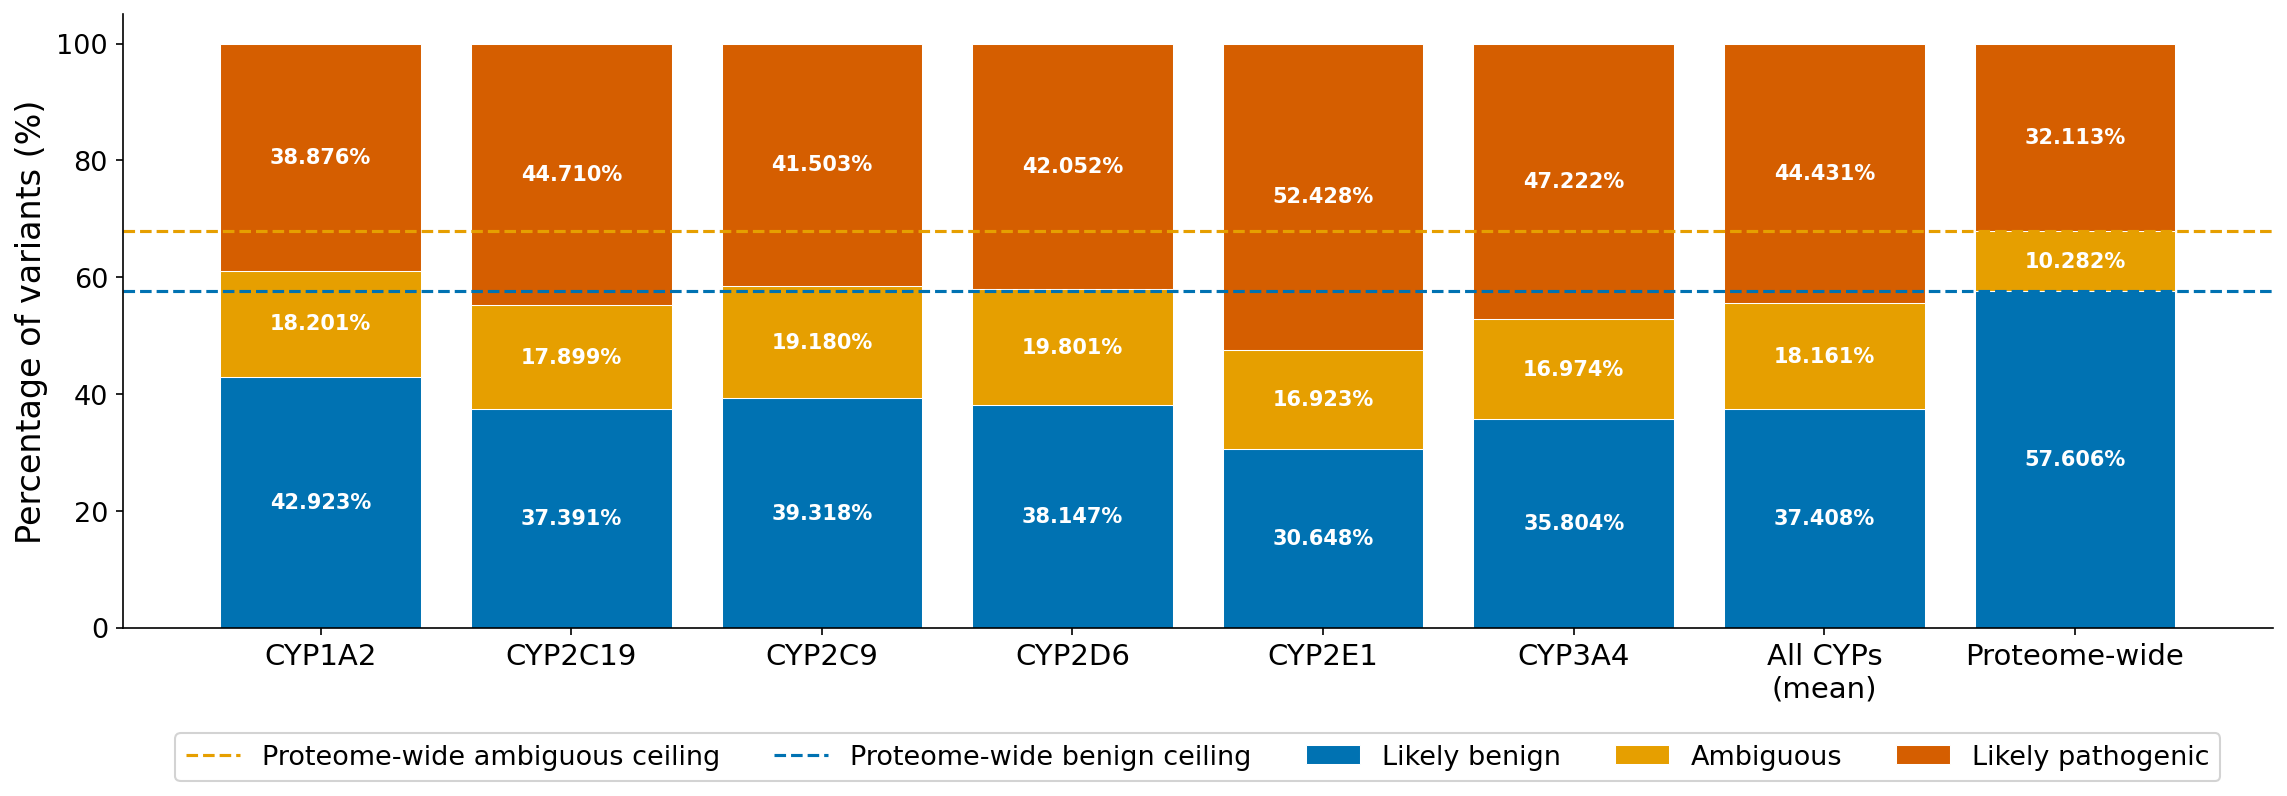

In [7]:
PALETTE = {
    'likely_benign': '#0072B2',
    'ambiguous': '#E69F00',
    'likely_pathogenic': '#D55E00',
}

# Build percentage dataframe: one row per protein + 'All CYPs' + 'Genome-wide'
rows = []
for gene, row in per_protein.iterrows():
    rows.append({
        'label': gene,
        **{cls: row[f'{cls}_pct'] for cls in CLASS_ORDER}
    })

# All CYPs combined
rows.append({
    'label': 'All CYPs\n(mean)',
    **{cls: cyp_pct.get(cls, 0) for cls in CLASS_ORDER}
})

# Genome-wide
rows.append({
    'label': 'Proteome-wide\n',
    **{cls: GENOME_PCT[cls] for cls in CLASS_ORDER}
})

plot_df = pd.DataFrame(rows).set_index('label')


def plot_stacked_class_bars(ax, plot_df, label_mode='pct'):
    """Stacked bar of AM class percentages per group, with proteome-wide reference
    lines. label_mode='pct' annotates each segment's percentage; label_mode='delta'
    annotates only the ambiguous-fraction delta vs. proteome-wide, above each bar."""
    bottoms = np.zeros(len(plot_df))
    x = np.arange(len(plot_df))

    for cls in CLASS_ORDER:
        vals = plot_df[cls].values
        ax.bar(x, vals, bottom=bottoms, color=PALETTE[cls],
               label=cls.replace('_', ' ').capitalize(), edgecolor='white', linewidth=0.5)
        if label_mode == 'pct':
            for i, (val, bot) in enumerate(zip(vals, bottoms)):
                if val > 3:
                    ax.text(i, bot + val / 2, f'{val:.3f}%',
                            ha='center', va='center', fontsize=10, color='white', fontweight='bold')
        bottoms += vals

    gw_amb = GENOME_PCT['ambiguous']
    gw_ben = GENOME_PCT['likely_benign']

    if label_mode == 'delta':
        for i, label in enumerate(plot_df.index):
            if 'Proteome-wide' in label:
                continue
            delta = plot_df.loc[label, 'ambiguous'] - gw_amb
            ax.text(i, bottoms[i] + 1.5, f'$\\Delta$ = {delta:+.2f}',
                    ha='center', va='bottom', fontsize=16, fontweight='bold')

    # Highlight the proteome-wide ambiguous / benign levels with horizontal lines
    ax.axhline(gw_ben + gw_amb, color='#E69F00', linestyle='--', linewidth=1.5,
               label='Proteome-wide ambiguous ceiling')
    ax.axhline(gw_ben, color='#0072B2', linestyle='--', linewidth=1.5,
               label='Proteome-wide benign ceiling')

    ax.set_xticks(x)
    ax.set_xticklabels(plot_df.index, fontsize=14)
    ax.set_ylabel('Percentage of variants (%)', fontsize=16)
    ax.tick_params(axis='y', labelsize=13)
    ax.set_ylim(0, 105)

    # Legend placed below the plot, in a single row
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
              fontsize=13, framealpha=0.85, ncol=len(ax.get_legend_handles_labels()[0]))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


fig, ax = plt.subplots(figsize=(16, 6))
plot_stacked_class_bars(ax, plot_df, label_mode='pct')
fig.tight_layout(rect=[0, 0.08, 1, 1])   # reserve bottom margin for the legend
plt.show()


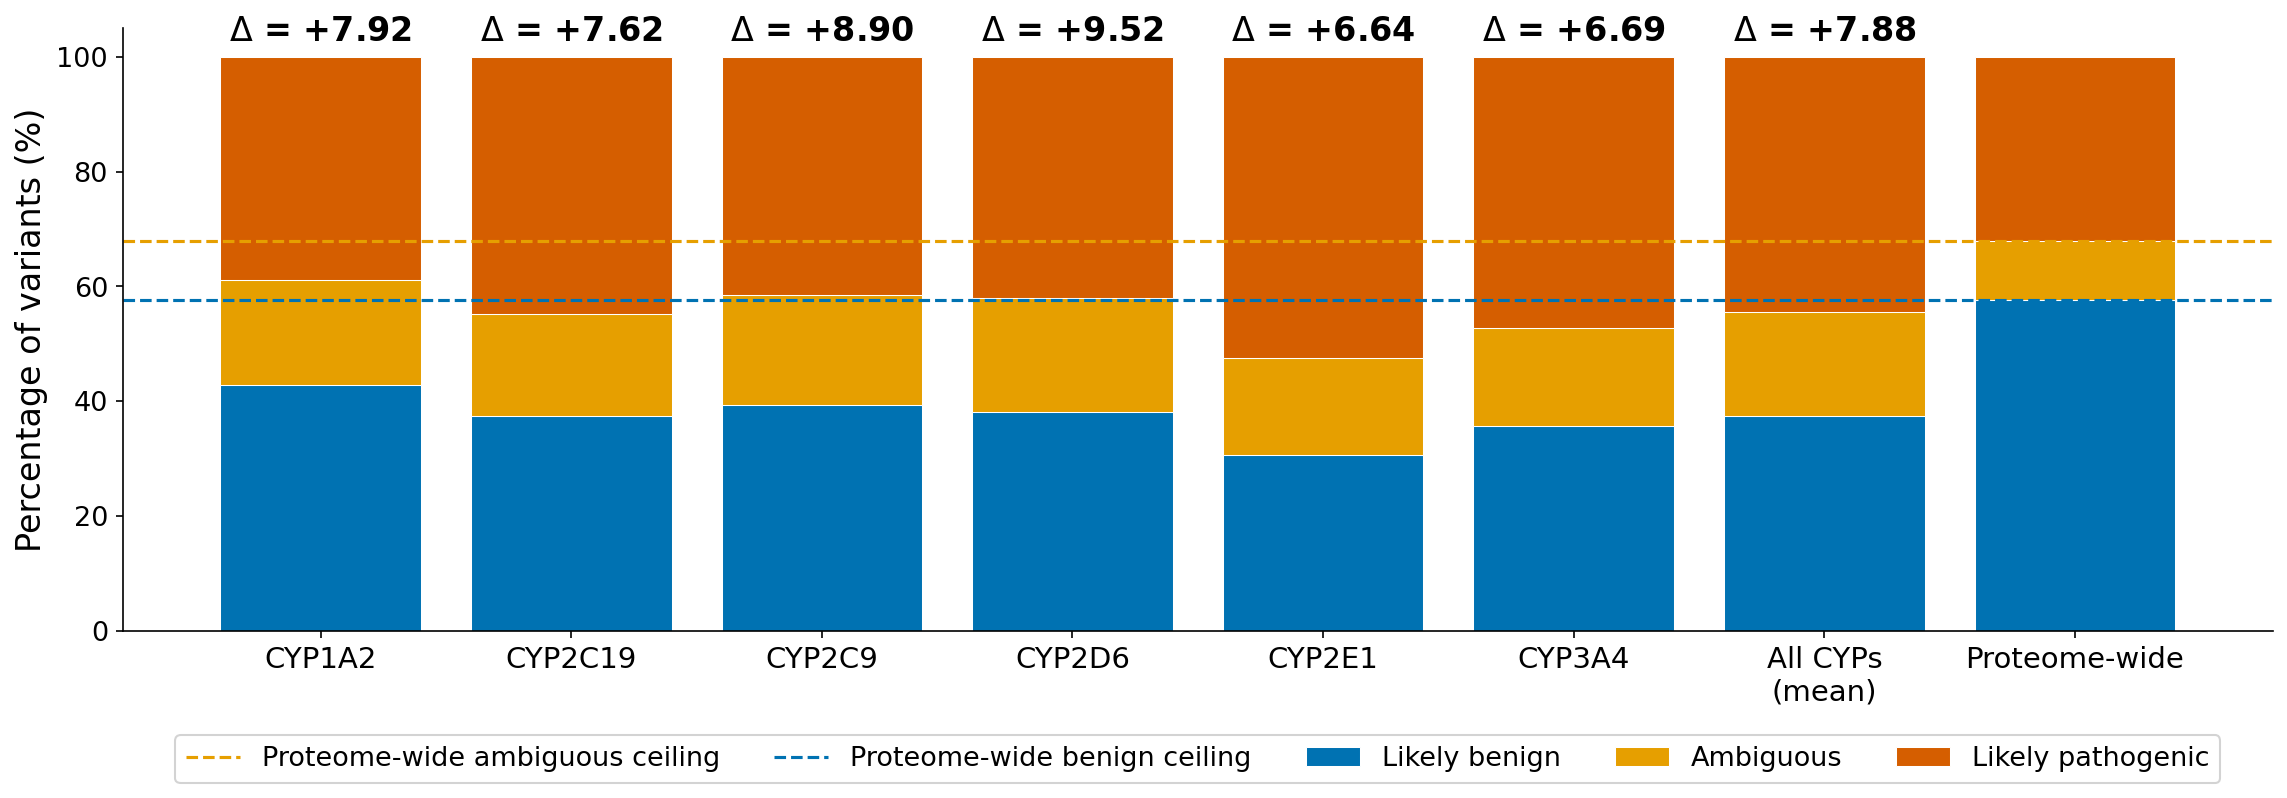

In [8]:
fig, ax = plt.subplots(figsize=(16, 6))
plot_stacked_class_bars(ax, plot_df, label_mode='delta')
fig.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


## Summary table

In [9]:
summary = plot_df.copy().round(3)
summary.columns = [c.replace('_', ' ').title() for c in summary.columns]
summary['Total Variants'] = (
    per_protein['total'].tolist()
    + [int(cyp_total)]
    + [GENOME_TOTAL]
)

# Highlight the ambiguous column
print('AlphaMissense class distribution summary (%):')
print(summary.to_string())

print(f'\nKey finding:')
print(f'  All 6 CYP proteins exceed the genome-wide ambiguous rate of {GENOME_PCT["ambiguous"]:.3f}%.')
print(f'  Combined CYP ambiguous fraction: {cyp_pct.get("ambiguous",0):.3f}%')
print(f'  That is {cyp_pct.get("ambiguous",0) / GENOME_PCT["ambiguous"]:.3f}x the genome-wide rate.')

AlphaMissense class distribution summary (%):
                  Likely Benign  Ambiguous  Likely Pathogenic  Total Variants
label                                                                        
CYP1A2                   42.923     18.201             38.876            9785
CYP2C19                  37.391     17.899             44.710            9291
CYP2C9                   39.318     19.180             41.503            9291
CYP2D6                   38.147     19.801             42.052            9424
CYP2E1                   30.648     16.923             52.428            9348
CYP3A4                   35.804     16.974             47.222            9538
All CYPs\n(mean)         37.408     18.161             44.431           56677
Proteome-wide\n          57.606     10.282             32.113        71000000

Key finding:
  All 6 CYP proteins exceed the genome-wide ambiguous rate of 10.282%.
  Combined CYP ambiguous fraction: 18.161%
  That is 1.766x the genome-wide rate.


## Priors vs. AM-calibrated prediction error (full dataset)

Tests whether four candidate explanatory factors -- residue position, substitution chemistry,
secondary structure, and substrate-recognition-site (SRS) distance -- are associated with *how
wrong AM's activity predictions actually are*, across the entire CYP2C9 dataset (all three AM
classes pooled).

Error is `|â_AM - a|`, where `â_AM` is the isotonic AM→activity calibration fit out-of-fold on
CLICK-seq data (from `cyp2c9_activity_prediction.ipynb`, exported as `am_calibrated_error.csv`)
and `a` is the measured CLICK-seq activity. Continuous priors (position, SRS distance) use
Spearman correlation; categorical priors (substitution chemistry, secondary structure) use
Kruskal-Wallis with an eta-squared effect size.

In [10]:
error_df = pd.read_csv(f'{DATA_DIR}/am_calibrated_error.csv')
cyp2c9_err = (all_cyp[all_cyp['Gene name'] == 'CYP2C9']
              .merge(error_df, left_on=['a.a.1', 'position', 'a.a.2'],
                     right_on=['ref', 'pos', 'alt'], how='inner'))
print(f'CYP2C9 variants with both AM class and AM-calibrated prediction error: {len(cyp2c9_err):,}')


def eta_squared_kruskal(groups):
    """Effect size for Kruskal-Wallis (eta-squared approximation): (H - k + 1) / (n - k)."""
    all_vals = np.concatenate(groups)
    n = len(all_vals)
    h_stat, p = kruskal(*groups)
    eta2 = (h_stat - len(groups) + 1) / (n - len(groups))
    return h_stat, p, max(eta2, 0.0)

CYP2C9 variants with both AM class and AM-calibrated prediction error: 6,141


### Setup: amino-acid chemistry groups, secondary structure, and substrate-recognition-site distances

Shared building blocks for the substitution-chemistry, secondary-structure, and SRS-distance
tests below.

In [11]:
AA_ORDER = list('ACDEFGHIKLMNPQRSTVWY')

# Biochemical groups for ordering and colouring
AA_GROUPS = {
    'Nonpolar':  list('GAVLIMPFW'),
    'Polar':     list('STCYNQ'),
    'Positive':  list('RKH'),
    'Negative':  list('DE'),
}
AA_GROUP_COLOR = {'Nonpolar': '#90A4AE', 'Polar': '#66BB6A',
                  'Positive': '#42A5F5', 'Negative': '#EF5350'}


def aa_group(aa):
    for grp, members in AA_GROUPS.items():
        if aa in members:
            return grp
    return 'Other'


The SecStrAnnotator output uses structure-chain indices. The last structure position (471)
corresponds to protein residue 490 (the C-terminal residue), giving an offset of 19. All SSE
positions below are corrected to full protein coordinates via `protein_pos = struct_pos + 19`.

In [12]:
with open(f'{DATA_DIR}/query-detected.sses.json') as f:
    sse_data = json.load(f)['query']['secondary_structure_elements']

with open(f'{DATA_DIR}/query-sequence.json') as f:
    seq_data = json.load(f)[0]

STRUCT_OFFSET = 490 - seq_data['end']   # struct pos 471 (last in chain) → protein pos 490; offset = 19

# Canonical type labels (collapse minor helix variants to parent types)
SSE_TYPE_MAP = {
    'H': 'Alpha helix',
    'h': '3₁₀ helix',
    'G': 'Pi helix',
    'E': 'Beta strand',
    'B': 'Beta bridge',
}
SSE_COLORS = {
    'Alpha helix': '#E53935',
    '3₁₀ helix':   '#FB8C00',
    'Pi helix':    '#8E24AA',
    'Beta strand': '#1E88E5',
    'Beta bridge': '#00ACC1',
    'Loop/Coil':   '#78909C',
}

# Build position → SS-type lookup (protein coordinates)
pos_to_ss = {}
for sse in sse_data:
    ss_label = SSE_TYPE_MAP.get(sse['type'], 'Loop/Coil')
    for struct_pos in range(sse['start'], sse['end'] + 1):
        protein_pos = struct_pos + STRUCT_OFFSET
        pos_to_ss[protein_pos] = ss_label


def get_ss(protein_pos):
    return pos_to_ss.get(protein_pos, 'Loop/Coil')


# Apply to CYP2C9 variants
cyp2c9 = all_cyp[all_cyp['Gene name'] == 'CYP2C9'].copy()
cyp2c9['ss_type'] = cyp2c9['position'].apply(get_ss)

positions = sorted(cyp2c9['position'].unique())
window = 15   # rolling-mean window (residues) for the along-sequence error plot below

### Substrate-recognition-site distance in CYP2C9

Uses the AlphaFold structure (AF-P11712-F1-model_v6.pdb) to compute Cα-Cα Euclidean distances
(Ångströms) between residues, used below to define distance to the substrate-recognition sites
(SRS1-6).

**Hypothesis:** pathogenic variants cluster closer to the substrate-recognition machinery; benign
variants are more peripheral; ambiguous variants occupy an intermediate zone.

In [13]:
PDB_PATH = f'{DATA_DIR}/AF-P11712-F1-model_v6.pdb'

parser = PDB.PDBParser(QUIET=True)
struct = parser.get_structure('cyp2c9', PDB_PATH)
chain = struct[0]['A']

ca_coords = {res.get_id()[1]: res['CA'].get_vector() for res in chain if 'CA' in res}
_coords = np.array([v.get_array() for v in ca_coords.values()])
_centroid = _coords.mean(axis=0)
_rg = np.sqrt(((_coords - _centroid) ** 2).sum(axis=1).mean())
_max_dist = cdist(_coords, _coords).max()

print('─' * 60)
print('CYP2C9 (AF-P11712-F1) structure summary')
print(f'  Residues with Cα     : {len(_coords)}')
print(f'  Radius of gyration   : {_rg:.3f} Å')
print(f'  Max Cα–Cα span       : {_max_dist:.3f} Å  (longest end-to-end distance)')
print('─' * 60)

────────────────────────────────────────────────────────────
CYP2C9 (AF-P11712-F1) structure summary
  Residues with Cα     : 490
  Radius of gyration   : 23.834 Å
  Max Cα–Cα span       : 89.077 Å  (longest end-to-end distance)
────────────────────────────────────────────────────────────


#### Structural distance priors vs. prediction error: SRS membership, not single-residue distance

**Minimum distance to any of the 6 substrate-recognition sites
(SRS1-6)**, where each SRS is defined by its real secondary-structure element(s), not a hand-picked
anchor-residue list:

| SRS | Structural element(s) | Residues (CYP2C9, UniProt numbering) |
|---|---|---|
| SRS1 | β-strand 1_5 + helix B' (B-C loop) | 96-97, 101-107 |
| SRS2 | helix F | 192-209 |
| SRS3 | helix G | 229-254 |
| SRS4 | helix I | 284-316 |
| SRS5 | β-strand 1_4 (+ neighboring loop, not independently defined below -- see note) | 368-369 |
| SRS6 | β-strands 4_1 + 4_2 | 473-474, 478-479 |

These boundaries were obtained by actually running **SecStrAnnotator 2.3** (Midlik et al. 2019) to
structurally align our CYP2C9 AlphaFold model against SecStrAnnotator's own bundled cytochrome-P450-fold
reference template (PDB 2NNJ, chain A -- the exact template the tool's authors ship for this family,
using this same canonical helix/strand nomenclature):
`dotnet SecStrAnnotator.dll . 2nnj,A cyp2c9q,A`. Alignment confidence (lower = better) for the elements
used here: I=0.42, 1-4=0.31, 1-5=0.87, B'=0.99, F=2.11, 4-1=1.69, 4-2=1.32, G=5.43 (weaker, but matched).

**Offset check**: the tool's own label→auth numbering table (`cyp2c9q-label2auth.tsv`) confirms 0/490
mismatches between structure (label) and protein (auth/UniProt) numbering for our query -- i.e. no
offset correction is needed here (unlike the original `query-detected.sses.json` file used for the
secondary-structure-type analysis above, which came from a differently-numbered structure and needed the
+19 correction).

`dist_srs6` below is the minimum Cα-Cα distance from a residue position to **any** residue in the union
of all six SRS sets.


In [14]:
# SRS1-6 boundaries come directly from running SecStrAnnotator 2.3 to structurally
# align our CYP2C9 AlphaFold model against the tool's own bundled CYP450-fold
# template (PDB 2NNJ, chain A), then reading off the matched element ranges --
# not hand-picked residue numbers (see markdown above for the exact command and
# alignment-confidence values).
with open(f'{DATA_DIR}/cyp2c9_srs_annotated.sses.json') as f:
    _srs_sse_data = json.load(f)
_srs_key = next(iter(_srs_sse_data))
_srs_elements = {sse['label']: (sse['start'], sse['end'])
                 for sse in _srs_sse_data[_srs_key]['secondary_structure_elements']}


def min_dist_to_set(pos, residue_set, coords=ca_coords):
    if pos not in coords:
        return np.nan
    return min((coords[pos] - coords[r]).norm() for r in residue_set if r in coords)


def _elem_range(label):
    lo, hi = _srs_elements[label]
    return set(range(lo, hi + 1))

SRS1 = _elem_range('1-5') | _elem_range("B'")   # beta-strand 1_5 + helix B' (B-C loop)
SRS2 = _elem_range('F')                         # helix F
SRS3 = _elem_range('G')                         # helix G
SRS4 = _elem_range('I')                         # helix I
SRS5 = _elem_range('1-4')                       # beta-strand 1_4 (no independently-defined loop buffer, see markdown)
SRS6 = _elem_range('4-1') | _elem_range('4-2')  # beta-strands 4_1 + 4_2

SRS_ALL = sorted(SRS1 | SRS2 | SRS3 | SRS4 | SRS5 | SRS6)
print(f'SRS element ranges used: ' + ', '.join(
    f'{lbl}={_srs_elements[lbl][0]}-{_srs_elements[lbl][1]}'
    for lbl in ["1-5", "B'", 'F', 'G', 'I', '1-4', '4-1', '4-2']))
print(f'Combined SRS1-6 residue set: {len(SRS_ALL)} residues -> {SRS_ALL}')

dist_srs6 = {p: min_dist_to_set(p, SRS_ALL) for p in ca_coords}

SRS element ranges used: 1-5=96-97, B'=101-107, F=192-209, G=229-254, I=284-316, 1-4=368-369, 4-1=473-474, 4-2=478-479
Combined SRS1-6 residue set: 92 residues -> [96, 97, 101, 102, 103, 104, 105, 106, 107, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 368, 369, 473, 474, 478, 479]


Full dataset: Spearman(position, |AM-calibrated prediction error|) = -0.002  (p=8.577e-01, n=6141)


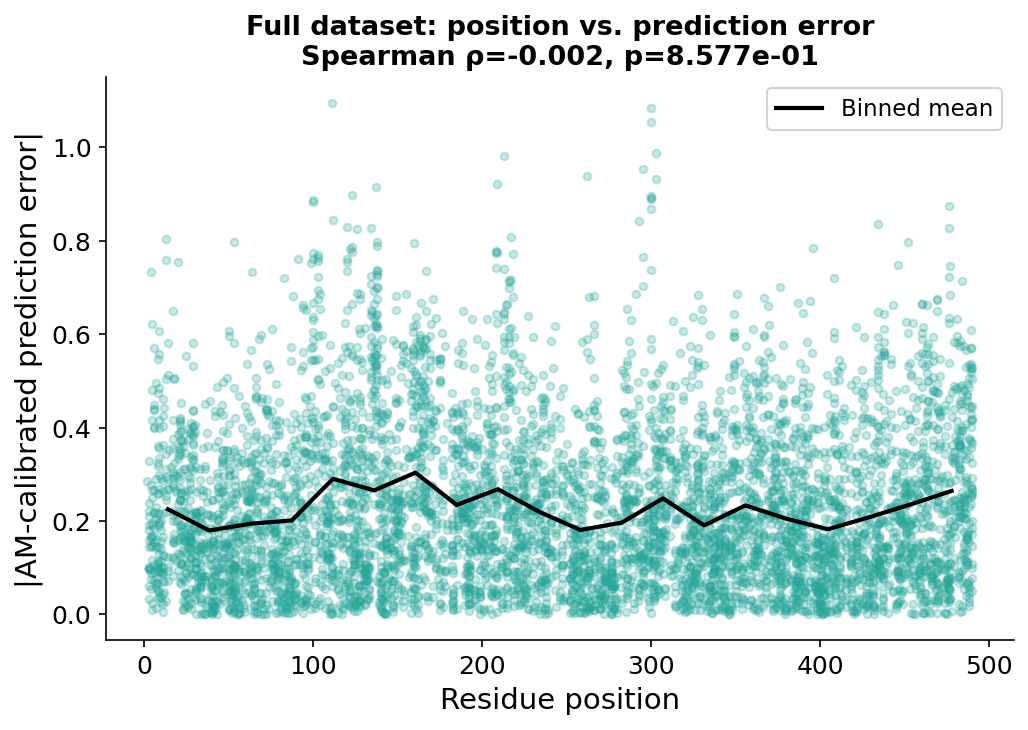

In [15]:
r_pos_err_all, p_pos_err_all = spearmanr(cyp2c9_err['position'], cyp2c9_err['am_error'])
print(f'Full dataset: Spearman(position, |AM-calibrated prediction error|) = '
      f'{r_pos_err_all:.3f}  (p={p_pos_err_all:.3e}, n={len(cyp2c9_err)})')

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(cyp2c9_err['position'], cyp2c9_err['am_error'], color='#26A69A', alpha=0.25, s=14)
bins = np.linspace(cyp2c9_err['position'].min(), cyp2c9_err['position'].max(), 21)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_idx = np.clip(np.digitize(cyp2c9_err['position'].values, bins) - 1, 0, len(bin_centers) - 1)
bin_means = pd.Series(cyp2c9_err['am_error'].values).groupby(bin_idx).mean().reindex(range(len(bin_centers)))
ax.plot(bin_centers, bin_means.values, color='black', linewidth=2, label='Binned mean')
ax.tick_params(axis='both', labelsize=12)
ax.set_xlabel('Residue position', fontsize=14)
ax.set_ylabel('|AM-calibrated prediction error|', fontsize=14)
ax.set_title(f'Full dataset: position vs. prediction error\nSpearman \u03c1={r_pos_err_all:.3f}, p={p_pos_err_all:.3e}',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

Full dataset: Kruskal-Wallis(WT substitution chemistry, prediction error) H=19.954  p=1.735e-04  eta2=0.003  n=6141


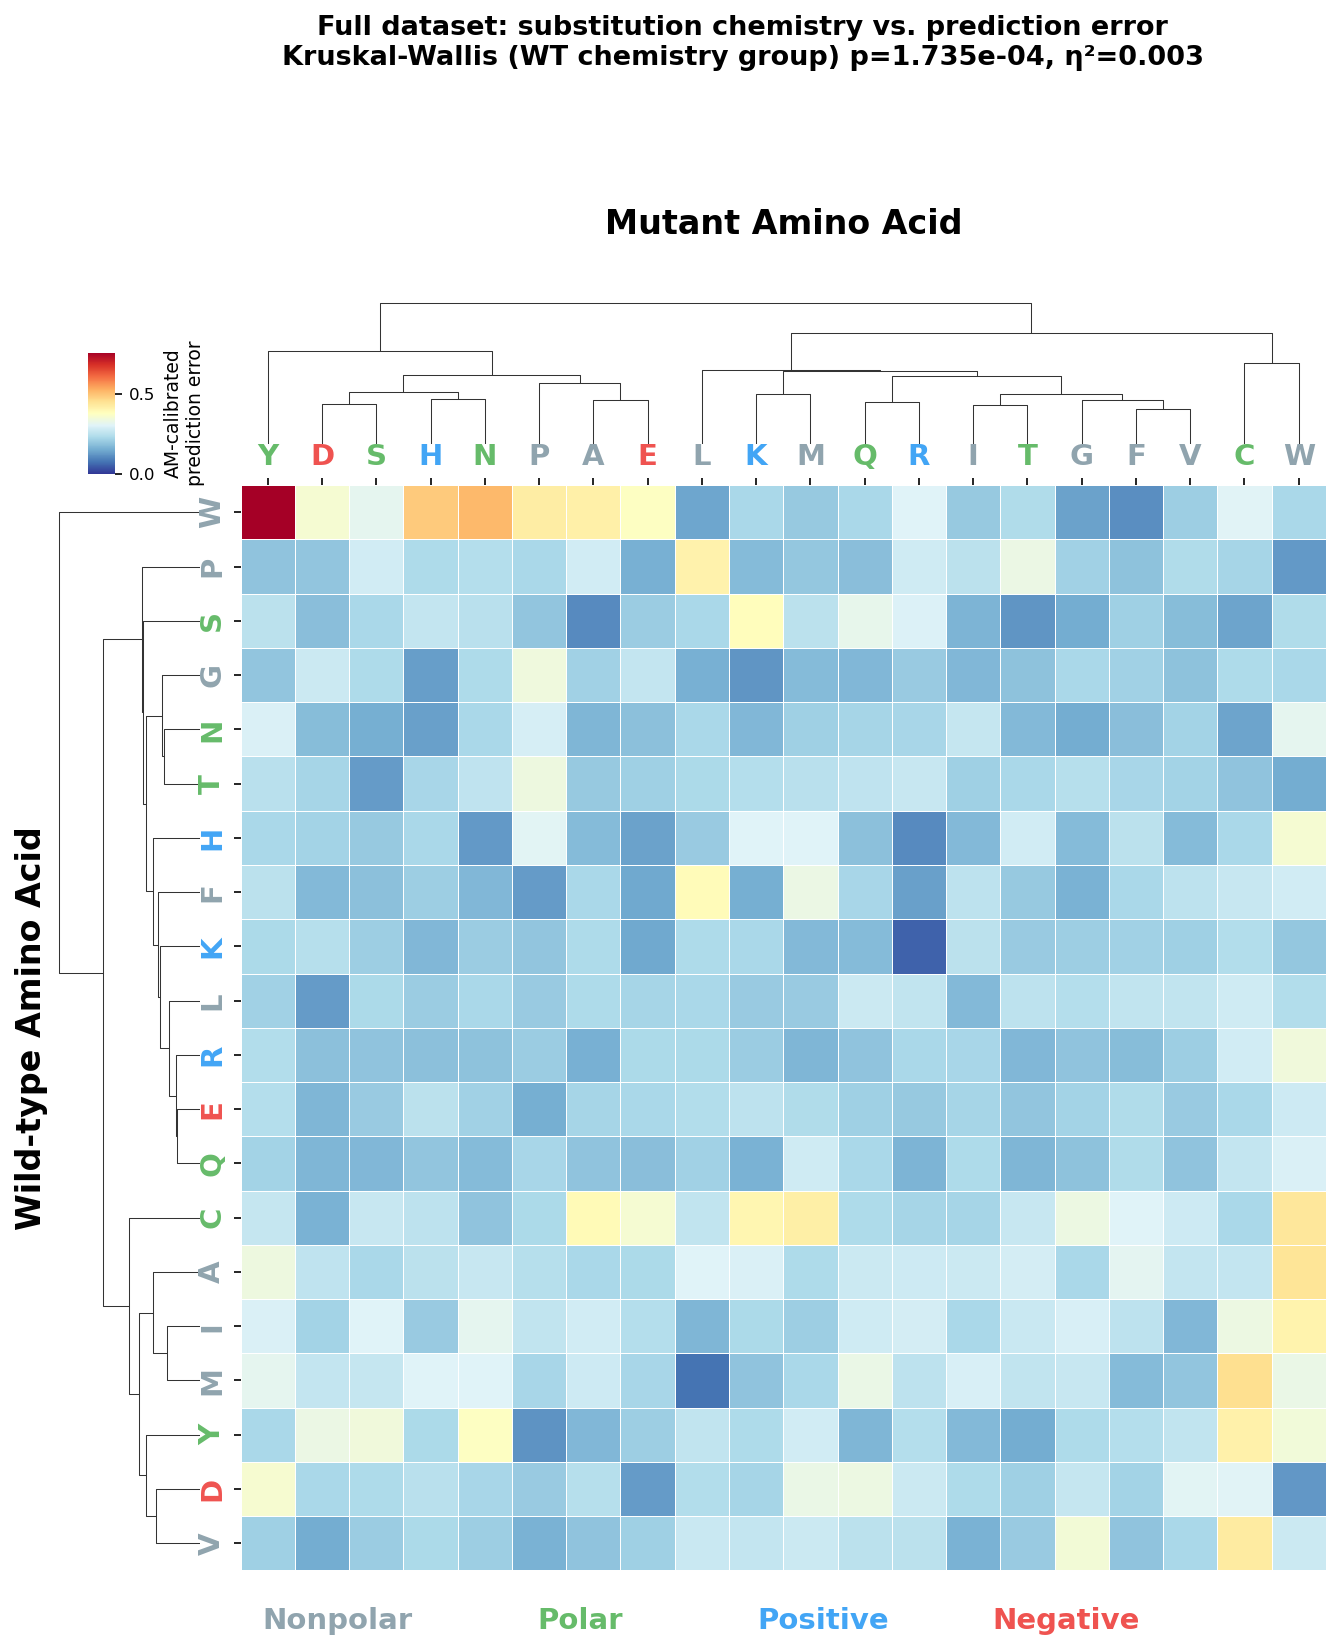

WT AA cluster order (by mean-error substitution profile):
  W  P  S  G  N  T  H  F  K  L  R  E  Q  C  A  I  M  Y  D  V


In [16]:
all_err_chem = cyp2c9_err.copy()
all_err_chem['wt_group'] = all_err_chem['ref'].apply(aa_group)

present_groups_all = [g for g in AA_GROUPS if (all_err_chem['wt_group'] == g).sum() >= 3]
groups_chem_all     = [all_err_chem.loc[all_err_chem['wt_group'] == g, 'am_error'].values for g in present_groups_all]
h_chem_all, p_chem_all, eta2_chem_all = eta_squared_kruskal(groups_chem_all)
print(f'Full dataset: Kruskal-Wallis(WT substitution chemistry, prediction error) '
      f'H={h_chem_all:.3f}  p={p_chem_all:.3e}  eta2={eta2_chem_all:.3f}  n={len(all_err_chem)}')

# ── Heatmap: mean |AM-calibrated prediction error| per (WT, mutant) pair,
# hierarchically clustered (Ward linkage / Euclidean distance): each amino
# acid is clustered by
# the similarity of its full 20-dim profile (its row/column of mean error
# across all 20 possible substitution partners), not just by a coarse
# 4-category chemistry group.
err_mat = (all_err_chem.groupby(['ref', 'alt'])['am_error']
           .mean()
           .unstack(fill_value=np.nan)
           .reindex(index=AA_ORDER, columns=AA_ORDER))
err_mat_clust = (err_mat.fillna(all_err_chem['am_error'].mean())
                 .rename_axis('Wild-type amino acid', axis=0)
                 .rename_axis('Mutant amino acid', axis=1))

cg = sns.clustermap(
    err_mat_clust,
    method='ward',
    metric='euclidean',
    cmap='RdYlBu_r',
    vmin=0,
    figsize=(9, 9),
    linewidths=0.3,
    linecolor='white',
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=0.12,
    cbar_pos=(0.015, 0.88, 0.02, 0.09),
    cbar_kws={'label': 'AM-calibrated\nprediction error'},
)
cg.cax.yaxis.label.set_fontsize(9)
cg.cax.tick_params(labelsize=8)
gap = 0.03  # figure-fraction gap between tree and heatmap
col_pos = cg.ax_col_dendrogram.get_position()
cg.ax_col_dendrogram.set_position(
    [col_pos.x0, col_pos.y0 + gap, col_pos.width, col_pos.height])
row_pos = cg.ax_row_dendrogram.get_position()
cg.ax_row_dendrogram.set_position(
    [row_pos.x0 - gap, row_pos.y0, row_pos.width, row_pos.height])

cg.ax_heatmap.xaxis.tick_top()
cg.ax_heatmap.xaxis.set_label_position('top')
cg.ax_heatmap.yaxis.tick_left()
cg.ax_heatmap.yaxis.set_label_position('left')
cg.ax_heatmap.set_xlabel('')
cg.ax_heatmap.set_ylabel('')
cg.ax_col_dendrogram.set_title('Mutant Amino Acid', fontsize=16, pad=30)
_rp = cg.ax_row_dendrogram.get_position()
cg.fig.text(
    _rp.x0 - 0.015, _rp.y0 + _rp.height / 2,
    'Wild-type Amino Acid',
    fontsize=16, rotation=90, ha='center', va='center', fontweight='bold'
)
for label in cg.ax_heatmap.get_xticklabels():
    label.set_color(AA_GROUP_COLOR[aa_group(label.get_text())])
    label.set_fontweight('bold')
    label.set_rotation(0)
    label.set_fontsize(14)
for label in cg.ax_heatmap.get_yticklabels():
    label.set_color(AA_GROUP_COLOR[aa_group(label.get_text())])
    label.set_fontweight('bold')
    label.set_fontsize(14)
for i, (grp, color) in enumerate(AA_GROUP_COLOR.items()):
    cg.fig.text(
        0.2 + i * 0.18, 0.02, grp,
        color=color, fontsize=14, fontweight='bold',
        ha='center', va='bottom',
    )
cg.fig.suptitle(
    f'Full dataset: substitution chemistry vs. prediction error\n'
    f'Kruskal-Wallis (WT chemistry group) p={p_chem_all:.3e}, \u03b7\u00b2={eta2_chem_all:.3f}',
    fontsize=13, fontweight='bold', y=1.22,
)
plt.show()

cluster_order_err = [AA_ORDER[i] for i in cg.dendrogram_row.reordered_ind]
print('WT AA cluster order (by mean-error substitution profile):')
print('  ' + '  '.join(cluster_order_err))

Full dataset: Kruskal-Wallis(secondary structure, prediction error) H=13.029  p=2.311e-02  eta2=0.001  n=6141  (types: ['Loop/Coil', 'Beta bridge', 'Alpha helix', 'Beta strand', '3₁₀ helix', 'Pi helix'])


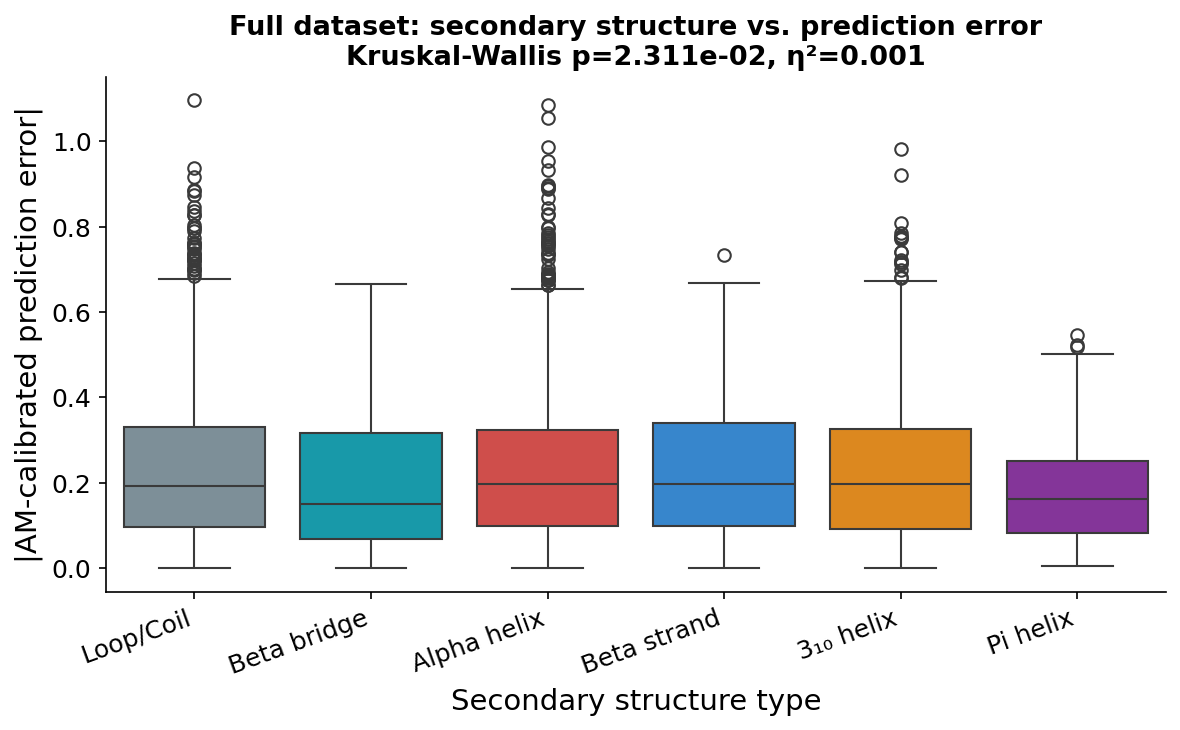

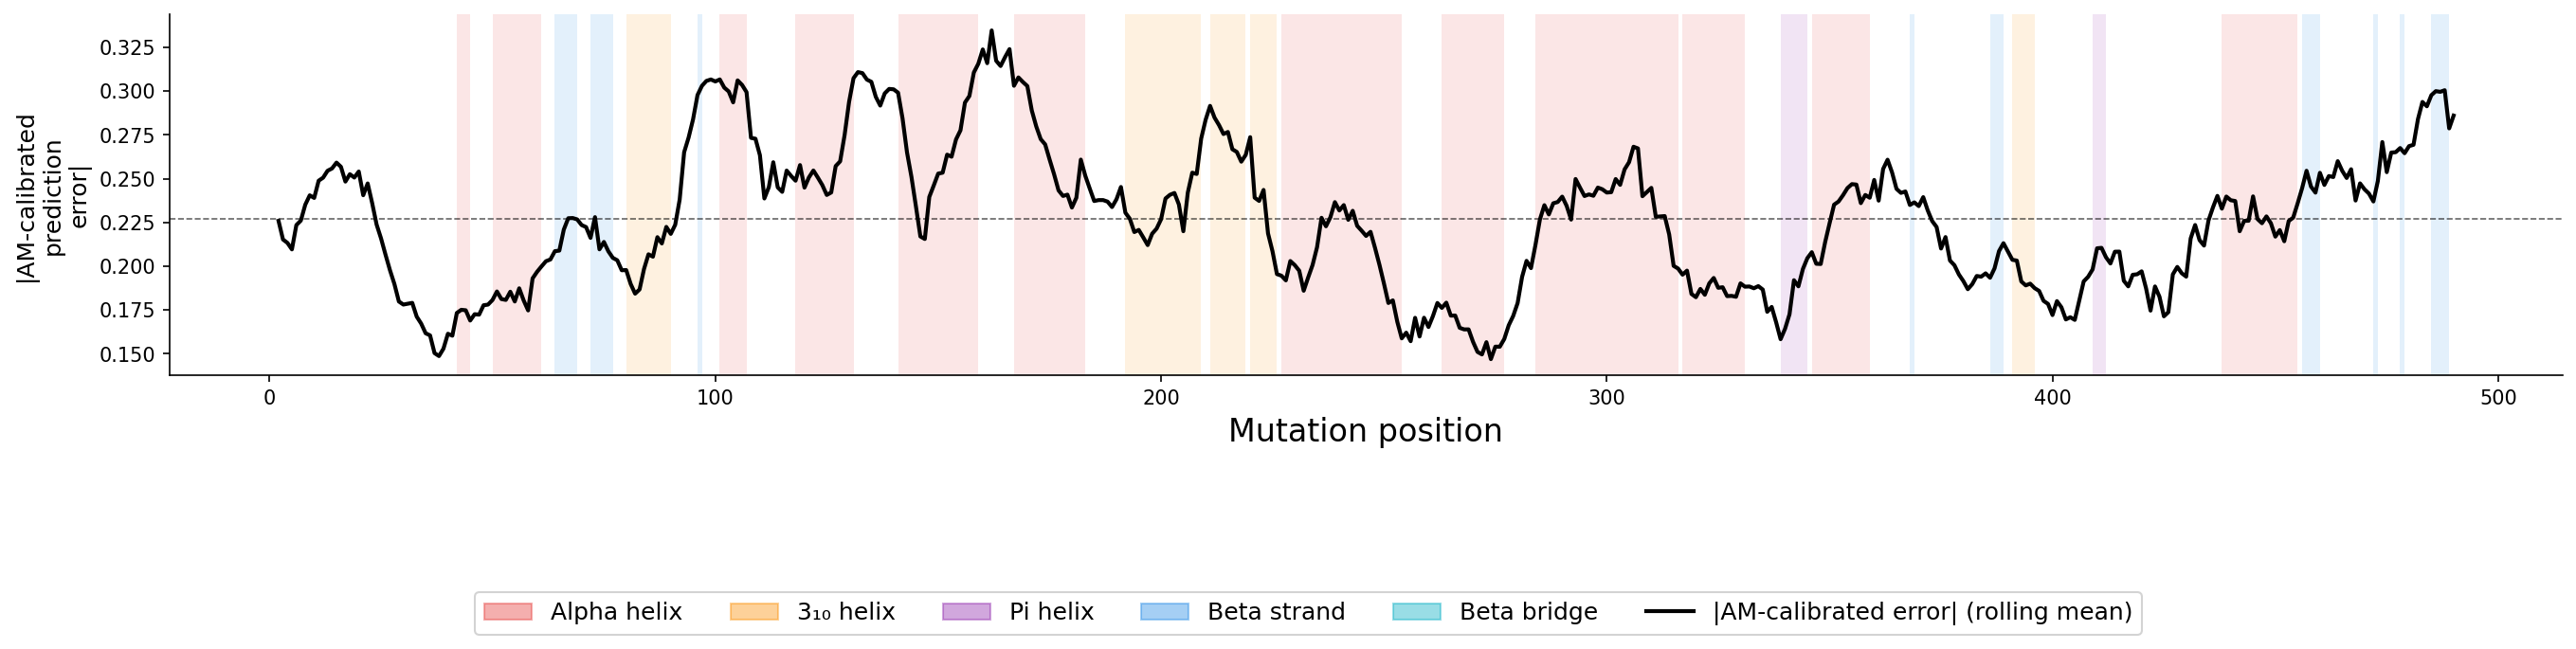

In [17]:
all_err_ss = cyp2c9_err.merge(cyp2c9[['position', 'ss_type']].drop_duplicates('position'),
                               on='position', how='left')

ss_present_all = [t for t in all_err_ss['ss_type'].dropna().unique()
                  if (all_err_ss['ss_type'] == t).sum() >= 3]
groups_ss_all   = [all_err_ss.loc[all_err_ss['ss_type'] == t, 'am_error'].values for t in ss_present_all]
h_ss_all, p_ss_all, eta2_ss_all = eta_squared_kruskal(groups_ss_all)
print(f'Full dataset: Kruskal-Wallis(secondary structure, prediction error) '
      f'H={h_ss_all:.3f}  p={p_ss_all:.3e}  eta2={eta2_ss_all:.3f}  n={len(all_err_ss)}  (types: {ss_present_all})')

fig, ax = plt.subplots(figsize=(8, 5))
box_colors = [SSE_COLORS.get(t, '#78909C') for t in ss_present_all]
sns.boxplot(data=all_err_ss[all_err_ss['ss_type'].isin(ss_present_all)],
            x='ss_type', y='am_error', order=ss_present_all, hue='ss_type',
            palette=box_colors, legend=False, ax=ax)
ax.tick_params(axis='both', labelsize=12)
ax.set_xticks(range(len(ss_present_all)))
ax.set_xticklabels(ss_present_all, rotation=20, ha='right', fontsize=12)
ax.set_xlabel('Secondary structure type', fontsize=14)
ax.set_ylabel('|AM-calibrated prediction error|', fontsize=14)
ax.set_title(f'Full dataset: secondary structure vs. prediction error\n'
             f'Kruskal-Wallis p={p_ss_all:.3e}, \u03b7\u00b2={eta2_ss_all:.3f}', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# ── Error along sequence, with SS-type background shading ────────────────────
# Rolling mean of |AM-calibrated prediction error| vs. residue position, with
# secondary-structure background shading (sse_data / SSE_TYPE_MAP / SSE_COLORS /
# STRUCT_OFFSET, loaded above).
err_by_pos    = all_err_ss.groupby('position')['am_error'].mean().reindex(positions)
err_by_pos_sm = err_by_pos.rolling(window, center=True, min_periods=1).mean()
overall_err_mean = all_err_ss['am_error'].mean()

fig3, ax = plt.subplots(figsize=(18, 4.8))
ax.plot(positions, err_by_pos_sm.values, color='black', linewidth=2,
        label='|AM-calibrated error| (rolling mean)')
ax.axhline(overall_err_mean, color='black', linestyle='--', linewidth=0.8, alpha=0.6,
           label=f'Overall mean = {overall_err_mean:.3f}')

for sse in sse_data:
    p_start = sse['start'] + STRUCT_OFFSET
    p_end   = sse['end']   + STRUCT_OFFSET
    color   = SSE_COLORS.get(SSE_TYPE_MAP.get(sse['type'], 'Loop/Coil'), '#78909C')
    ax.axvspan(p_start, p_end, alpha=0.12, color=color, linewidth=0)

ss_patches   = [mpatches.Patch(color=c, alpha=0.4, label=t)
                for t, c in SSE_COLORS.items() if t != 'Loop/Coil']
line_handles = [plt.Line2D([0], [0], color='black', linewidth=2,
                            label='|AM-calibrated error| (rolling mean)')]
ax.set_xlabel('Mutation position', fontsize=16)
ax.set_ylabel('|AM-calibrated\nprediction\nerror|', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Explicit, absolute margins (not tight_layout's heuristic) so the legend
# (anchored in FIGURE coordinates, not axes-relative) can't collide with the
# x-axis label regardless of axes height.
fig3.subplots_adjust(left=0.055, right=0.99, top=0.93, bottom=0.40)
ax.legend(handles=ss_patches + line_handles, fontsize=12,
          loc='lower center', bbox_to_anchor=(0.5, 0.02), bbox_transform=fig3.transFigure,
          borderaxespad=0, ncol=len(ss_patches) + 1)
plt.show()

Full dataset: Spearman(min distance to any SRS1-6 residue, |AM-calibrated prediction error|) = -0.091  p=8.568e-13  n=6141


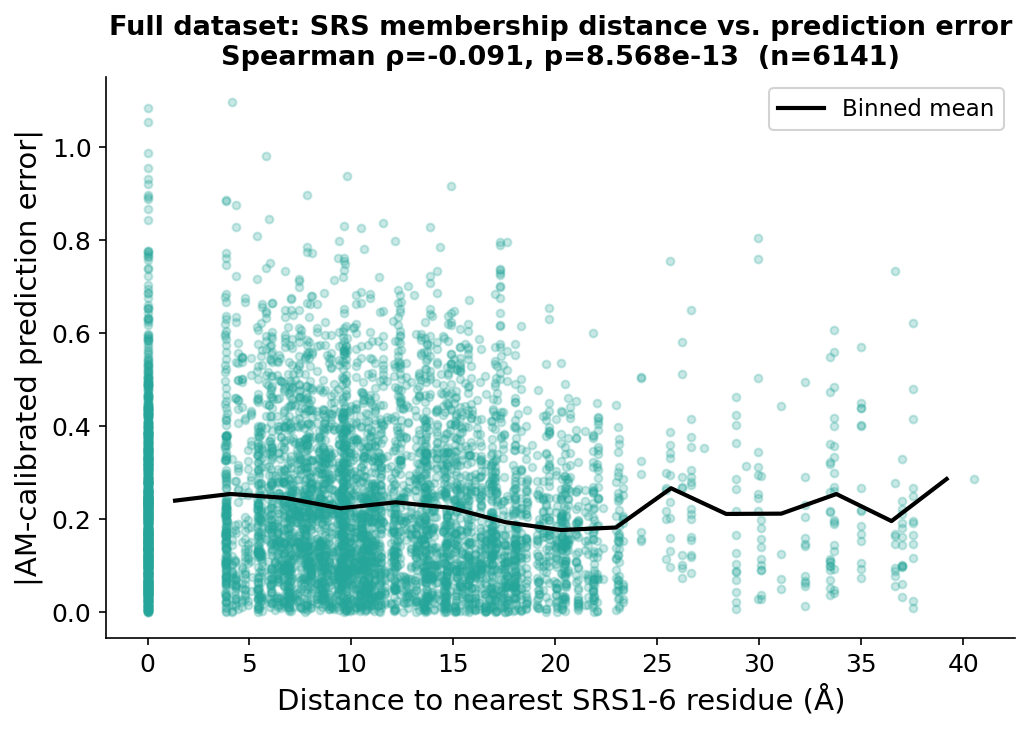

In [18]:
all_err_dist = cyp2c9_err.copy()
all_err_dist['dist_srs6'] = all_err_dist['position'].map(dist_srs6)

r_srs6_all, p_srs6_all = spearmanr(all_err_dist['dist_srs6'], all_err_dist['am_error'], nan_policy='omit')
n_srs6_all = all_err_dist['dist_srs6'].notna().sum()
print(f'Full dataset: Spearman(min distance to any SRS1-6 residue, |AM-calibrated prediction error|) = '
      f'{r_srs6_all:+.3f}  p={p_srs6_all:.3e}  n={n_srs6_all}')

fig, ax = plt.subplots(figsize=(7, 5))
sub_all = all_err_dist.dropna(subset=['dist_srs6'])
ax.scatter(sub_all['dist_srs6'], sub_all['am_error'], color='#26A69A', alpha=0.25, s=14)
bins = np.linspace(sub_all['dist_srs6'].min(), sub_all['dist_srs6'].max(), 16)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_idx = np.clip(np.digitize(sub_all['dist_srs6'].values, bins) - 1, 0, len(bin_centers) - 1)
bin_means = pd.Series(sub_all['am_error'].values).groupby(bin_idx).mean().reindex(range(len(bin_centers)))
ax.plot(bin_centers, bin_means.values, color='black', linewidth=2, label='Binned mean')
ax.tick_params(axis='both', labelsize=12)
ax.set_xlabel('Distance to nearest SRS1-6 residue (\u00c5)', fontsize=14)
ax.set_ylabel('|AM-calibrated prediction error|', fontsize=14)
ax.set_title(f'Full dataset: SRS membership distance vs. prediction error\n'
             f'Spearman \u03c1={r_srs6_all:.3f}, p={p_srs6_all:.3e}  (n={n_srs6_all})', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Substrate-discordant ClinPGx labels: same-study / same-endpoint control

ClinPGx (formerly PharmGKB) literature annotations record, for a given CYP2C9 variant, a functional
call (`claude_function`) associated with a specific drug. A variant whose functional call differs
depending on which drug it is evaluated against is direct evidence that a single substrate-agnostic
score cannot be right for every substrate simultaneously. The concern: pooling *any* two drug rows for
a variant, regardless of which study produced them or what endpoint they measured, could manufacture
apparent discordance out of study-to-study noise rather than genuine substrate-dependence. Below,
the discordant-variant fraction is recomputed restricted to drug pairs that share the same literature
citation (same study) or the same `Phenotype Categories` label (same endpoint type).

In [19]:
AA3_I7 = {
    'A':'Ala','C':'Cys','D':'Asp','E':'Glu','F':'Phe','G':'Gly',
    'H':'His','I':'Ile','K':'Lys','L':'Leu','M':'Met','N':'Asn',
    'P':'Pro','Q':'Gln','R':'Arg','S':'Ser','T':'Thr','V':'Val',
    'W':'Trp','Y':'Tyr'
}

pharmvar_i7          = pd.read_csv(f'{DATA_DIR}/pharmvar_cyp2c9_missense_mutations_single.csv')
allele_to_mutation_i7 = dict(zip(pharmvar_i7['Allele'], pharmvar_i7['Mutation']))

clinpgx_cyp2c9 = pd.read_csv(f'{DATA_DIR}/clinpgx_cyp2c9_variants.tsv', sep='\t', dtype=str)
print(f'{len(clinpgx_cyp2c9):,} ClinPGx CYP2C9 rows loaded')


def novel_alleles(variant_str):
    """Star alleles mentioned in a Variant field, excluding the CYP2C9*1 reference."""
    alleles = re.findall(r'CYP2C9\*\d+', str(variant_str))
    return [a for a in alleles if a != 'CYP2C9*1']


clinpgx_cyp2c9['novel'] = clinpgx_cyp2c9['Variant'].apply(novel_alleles)
single = clinpgx_cyp2c9[clinpgx_cyp2c9['novel'].apply(len) == 1].copy()
single['allele']   = single['novel'].apply(lambda x: x[0])
single['mutation'] = single['allele'].map(allele_to_mutation_i7)

resolved = single.dropna(subset=['mutation'])
resolved = resolved[resolved['Drugs'].notna() & (resolved['Drugs'].str.strip() != '')]
print(f'{len(resolved)} rows resolve to exactly one scorable PharmVar single-missense variant '
      f'(vs. CYP2C9*1 reference) and carry a specific drug annotation')


def _sig_priority(s):
    s = str(s).strip().lower()
    if s == 'yes': return 0
    if s == 'not stated': return 1
    return 2


def _parse_pval(s):
    s = str(s).strip()
    if not s or s.lower() == 'nan': return 1.0
    s = re.sub(r'^[=<>\u2264\u2265]+\s*', '', s)
    try:
        return float(s)
    except ValueError:
        return 1.0


def _parse_n(s):
    try:
        return float(str(s).strip())
    except (ValueError, AttributeError):
        return 0.0


def best_func(grp):
    """Best-evidence function label per (mutation, drug) group: non-uncertain rows
    preferred, then significance (yes > not stated > no), then p-value ascending,
    then total n descending."""
    non_unc = grp[grp['claude_function'] != 'uncertain function']
    pool    = non_unc if not non_unc.empty else grp
    best    = pool.sort_values(['_sig', '_pval', '_n'], ascending=[True, True, False])
    return best.iloc[0]['claude_function']


drugsmiles_i7   = pd.read_csv(f'{DATA_DIR}/drug_smiles_cyp.csv')
cyp2c9_drugs_i7 = set(drugsmiles_i7.loc[drugsmiles_i7['cyp'] == 'CYP2C9', 'drug'].str.lower())

resolved = resolved.copy()
resolved['_sig']  = resolved['Significance'].apply(_sig_priority)
resolved['_pval'] = resolved['P-Value'].apply(_parse_pval)
resolved['_n']    = resolved['# of Cases'].apply(_parse_n) + resolved['# of Controls'].apply(_parse_n)

long_i7 = (
    resolved.assign(Drug=resolved['Drugs'].str.split(r';\s*'))
    .explode('Drug')
    .assign(Drug=lambda d: d['Drug'].str.strip().str.lower())
    .query('Drug.notna() and Drug != ""')
)
long_i7 = long_i7[long_i7['Drug'].isin(cyp2c9_drugs_i7)].reset_index(drop=True)
print(f'{len(long_i7)} (variant, drug) literature rows after exploding multi-drug annotations '
      f'and keeping only documented CYP2C9 substrates')

1,150 ClinPGx CYP2C9 rows loaded
476 rows resolve to exactly one scorable PharmVar single-missense variant (vs. CYP2C9*1 reference) and carry a specific drug annotation
515 (variant, drug) literature rows after exploding multi-drug annotations and keeping only documented CYP2C9 substrates


--- Baseline (any study, any endpoint) ---
Baseline: 23 / 32 variants with >=2 drug annotations (71.9%) have a function label that differs depending on which drug is used (143 (variant, drug) pairs)

--- Same-study control (>=2 drugs share one citation for that variant) ---


Same-study: 2 / 9 variants with >=2 drug annotations (22.2%) have a function label that differs depending on which drug is used (53 (variant, drug) pairs)

--- Same-endpoint-type control (>=2 drugs share one Phenotype-Categories label) ---


Same-endpoint: 20 / 28 variants with >=2 drug annotations (71.4%) have a function label that differs depending on which drug is used (129 (variant, drug) pairs)


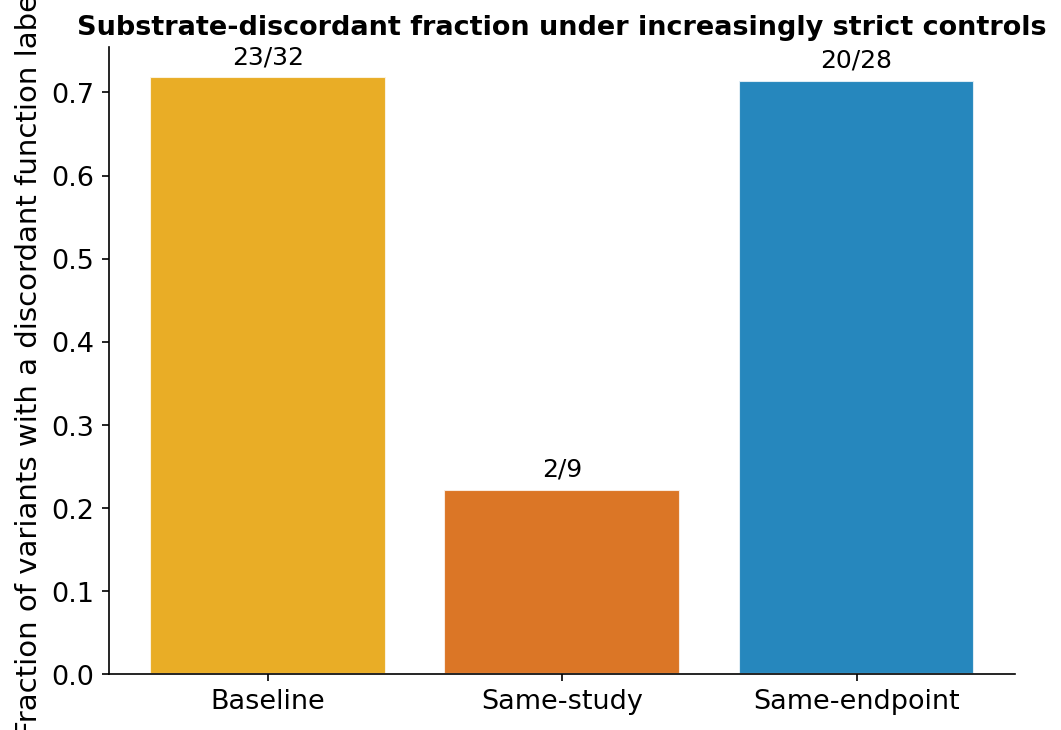

In [20]:
def discordant_fraction(df, label):
    """Fraction of variants whose best-evidence function label differs across
    the (drug) comparisons retained in df, restricted to variants with >= 2
    distinct drug annotations. Variants with only one drug annotation cannot,
    by construction, ever show cross-drug discordance, so including them in
    the denominator would understate the true discordant fraction."""
    per_pair = (df.groupby(['mutation', 'Drug'], sort=False)
                  .apply(best_func, include_groups=False)
                  .rename('claude_function').reset_index())
    n_drugs  = per_pair.groupby('mutation')['Drug'].nunique()
    eligible = n_drugs[n_drugs >= 2].index
    per_pair = per_pair[per_pair['mutation'].isin(eligible)]
    n_var    = per_pair['mutation'].nunique()
    variety  = per_pair.groupby('mutation')['claude_function'].nunique()
    het      = variety[variety >= 2].index
    n_het    = len(het)
    frac     = n_het / n_var if n_var else float('nan')
    print(f'{label}: {n_het} / {n_var} variants with >=2 drug annotations ({frac:.1%}) have a '
          f'function label that differs depending on which drug is used '
          f'({len(per_pair)} (variant, drug) pairs)')
    return dict(label=label, n_het=n_het, n_var=n_var, frac=frac)


print('--- Baseline (any study, any endpoint) ---')
res_base = discordant_fraction(long_i7, 'Baseline')

# ── Same-study control: keep only (variant, drug) rows whose literature
# citation is shared with >= 1 other drug for that same variant ────────────
lit_counts = long_i7.groupby(['mutation', 'Literature'])['Drug'].transform('nunique')
same_study = long_i7[lit_counts >= 2]
print('\n--- Same-study control (>=2 drugs share one citation for that variant) ---')
if same_study['mutation'].nunique() > 0:
    res_study = discordant_fraction(same_study, 'Same-study')
else:
    res_study = dict(label='Same-study', n_het=0, n_var=0, frac=float('nan'))
    print('No variant has >=2 distinct CYP2C9-substrate drugs backed by the same single citation -- '
          'as expected, this control is underpowered with the available literature.')

# ── Same-endpoint control: keep only (variant, drug) rows whose Phenotype
# Categories signature is shared with >= 1 other drug for that same variant ─
endpoint_counts = long_i7.groupby(['mutation', 'Phenotype Categories'])['Drug'].transform('nunique')
same_endpoint = long_i7[endpoint_counts >= 2]
print('\n--- Same-endpoint-type control (>=2 drugs share one Phenotype-Categories label) ---')
if same_endpoint['mutation'].nunique() > 0:
    res_endpoint = discordant_fraction(same_endpoint, 'Same-endpoint')
else:
    res_endpoint = dict(label='Same-endpoint', n_het=0, n_var=0, frac=float('nan'))
    print('No variant has >=2 distinct CYP2C9-substrate drugs sharing one endpoint-type label.')

# ── Bar chart: discordant fraction under each control ────────────────────────
results_i7 = [res_base, res_study, res_endpoint]
fig, ax = plt.subplots(figsize=(7, 5))
bar_colors = [PALETTE['ambiguous'], PALETTE['likely_pathogenic'], PALETTE['likely_benign']]
fracs = [r['frac'] if r['frac'] == r['frac'] else 0 for r in results_i7]
bars = ax.bar([r['label'] for r in results_i7], fracs, color=bar_colors, alpha=0.85, edgecolor='white')
for bar, r in zip(bars, results_i7):
    label = f"{r['n_het']}/{r['n_var']}" if r['n_var'] else 'n/a (underpowered)'
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, label,
            ha='center', va='bottom', fontsize=12)
ax.tick_params(axis='both', labelsize=13)
ax.set_ylabel('Fraction of variants with a discordant function label', fontsize=14)
ax.set_title('Substrate-discordant fraction under increasingly strict controls', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()